In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from scipy.stats import skew , kurtosis
import time
import tsplib95
import math

In [2]:
sys.path.append(os.path.abspath("../src"))
from populacao import Populacao
from pygenec.selecao.torneio import Torneio
from pygenec.cruzamento.edge_recombination import Edge_recombination
from pygenec.cruzamento.unponto import UmPonto

from pygenec.mutacao.inversion import Inversion
from pygenec.mutacao.swap import Swap

from pygenec.busca_local.opt_2 import Opt_2

from evolucao import Evolucao
from evolucao_tsp_classico import Evolucao_classica

from funcoes import Criar_Gif, Imagens_para_gif,Ate_convergir, Melhor_rota, Numero_de_geracoes, Arredondar_cima

In [3]:
sys.path.append(os.path.abspath("../data"))
problema = tsplib95.load(r"..\data\TSPLIB\tsp225.tsp")
solucao = tsplib95.load(r"..\data\TSPLIB\tsp225.opt.tour")

In [4]:
coordenadas = problema.node_coords
rota = solucao.tours[0]
rota = np.asarray(rota)-1

In [5]:
def adjacencias (dicionario):
    dist = []
    for i in coordenadas:
        linhas = []
        for j in coordenadas:
            soma = ((dicionario[i][0]-dicionario[j][0])**2) + ((dicionario[i][1]-dicionario[j][1])**2)
            raiz = soma**(1/2)
            linhas.append(raiz)
        dist.append(linhas)
    
    return dist

def fun(individuo):
    f = 0
    n = len(individuo)
    for i in range(n-1):
        local1 = individuo[i]
        local2 = individuo[i+1]
        distancia = dist[local1][local2]
        f += distancia
    f+= dist[individuo[-1]][individuo[0]]
    return f

def avaliacao(populacao):
    tpm = []
    for ind in populacao:
        tpm.append(fun(ind))
    tpm = np.asarray(tpm)
    return tpm

In [6]:
dist = adjacencias(coordenadas)
df = pd.DataFrame.from_dict(coordenadas, orient="index", columns=["x", "y"])

In [7]:
cromossos_totais = len(coordenadas)
tamanho_populacao = 3*(cromossos_totais)
geracao = Numero_de_geracoes(cromossos_totais)
Valor_otimizador = 0.10
pmut = 0.3

## Híbrido

In [8]:
Nome = "AG Híbrido"
tam = problema.name
Juncao = Nome +" " +tam

In [9]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao = Torneio(populacao)
cruzamento = Edge_recombination(tamanho_populacao)
mutacao = Inversion(pmut)
otimizador = Opt_2(dist)
evolucao = Evolucao(populacao,selecao,
                    cruzamento,mutacao,
                    otimizador,
                    Valor_otimizador,
                    geracao)

evolucao.nsele = round(tamanho_populacao/2)
evolucao.pcruz = 0.8

In [10]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 37147.00 | Melhor rota: [183 187 142 121  13  29 112 200 222 172  74  41 179 141  81  94  24 168
  68  59 100 114  65  96   4  35 134 144  98  15 104  38  66  39 218  46
 128  61 175 169 154 160 220 223 195 127 211 131  62  42  60 182 210 138
 208 196 105 217 198  75  10 205  25  82  36 177 106 118 140  97 113 167
  71  33 117 155  72  44 143  23  34 156 137 188   5 164 150 197 193 152
  80 206  77 119 161  28 166 178   9  48 110  55  57  52 153  99  16 176
 149 124 213  83 159 214  70  30  17  37 202  73 171  69  12 203 204   2
 219 186 123 216  14  26  63 115  88 209 103   8  78 173 145 192 122 116
 109  11 108   7  32  93 174   0  20  18  45  47 139 190 129  84  95  43
 102  22  50  64 221  91  27 189 199  40 132  86 130 194  87 163 165 125
 101  92 136 158 148 215 135 146 207   3  49   6 120 126  56 133 212 201
  79 111 170 107  67  53  51   1  58 162 191 151  85 181 185 147 157  76
  21  31  54  89  90  19 184 224 180]
Geração   2 | Melhor fitness: 36

In [11]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

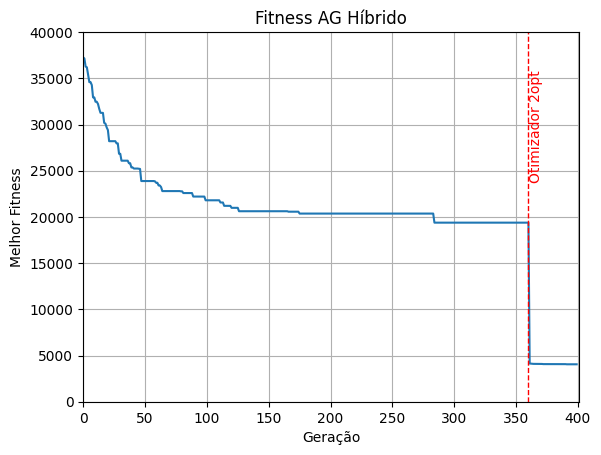

In [12]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")
linha_otmizador = geracao - (geracao*Valor_otimizador)
limite_y = Arredondar_cima(max(evo))

plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.axvline(x=linha_otmizador, color='r', linestyle='--', linewidth=1)
plt.text(linha_otmizador + 0.5, limite_y*0.6, 'Otimizador 2opt', rotation=90, color='red')
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [13]:
Melhor_rota(evolucao,df,tamanho_populacao,Juncao,Nome,Alpha =0.01)

### Resultados

In [14]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Híbrido
Assimetria:             -1.0668
Curtose:                2.7022
Desvio padrão:          6186.4173
Tempo de execução:      7130.58 s
Gerações até convergir: 391
----------------------------------------
Melhor fitness:         4051.0850
Melhor rota encontrada:
[222 115  59  60  61  62  63  64 109 110 111 112 113 114 117 185 186 116
 187  26 188 204 190 191 195 192 217 193 194 196 197 199   0   2   3   4
   5   6   7   8   9  10  11  13  14  15  16  17  18 202  19  20  21  22
  12  23 207  24  25 203  27  28  29 201 205  76  78  77 216 218 215  30
  31  34  32  33  35  36  37  38  39  40  41  42  43  45  44  47 223 198
 132 189 224  46   1  58  57 206  48  49  50  56  55  54  51  52  53  69
  70  71  72  73  75  74  99  98  97  96  95 208  94  79  80 220  93  92
  82  81  84  85  83 209  86  89  91  90  87  88 100 101  68  67  65  66
 103 102 219 104 105 106 107 108 124 125 126 127 128 221 129 210 130 131
 163 214 133 134 182 135 136 137 138 139 140 141 200 142 143

## Clássico

In [15]:
Nome = "AG Clássico"
tam = problema.name
Juncao = Nome +" " +tam

In [16]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao= Torneio(populacao)
cruzamento = UmPonto(tamanho_populacao)
mutacao = Swap(pmut)
evolucao = Evolucao_classica(populacao,selecao,
                    cruzamento,mutacao)

evolucao.nsele = round(tamanho_populacao/2)
evolucao.pcruz = 0.8

In [17]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 37495.96 | Melhor rota: [ 57 211  25  70  58   2  59 181  50  94 107 128  54  43 167  90  73 137
 147 173  17  51  52  13  26 108  41 213 131  99  22  86 214 187 202 209
  42 191  20  19 224  74 103 124  67 126 163 178 143 145 206  34 127 175
 116 148  21  39  65 216   3 114 201  37  12 117 154 196 194 207 125 200
 221  66  48 121 119 122  81 100 157 171  80  87 208 138 193 111 144  46
 160 123 168  78  31  32 222 152 112 134  45  69 190 198 199   1 165  23
  27  60 106  79  35  28   7 177 156 205  71  75 129 146  98 161  85  96
 223  97   6  30 204  76 220  49  10  44 164 104 179 158 176  61 195   5
 136 151  64  40 218 153 212 197 132 169 142  88  38 150 182 172  89 141
  95  92 115 113 133  53  15 210  36   9 188  11  18 192 184 189  29  24
  68  62  63 170  82  83 105 135 166 120  14  16 101 155   4 215 162  84
 130 186 217 185 109 149  77  93  91 180 102 174 203  33  56 110 219   8
  55 159  72 140 118 183  47   0 139]
Geração   2 | Melhor fitness: 36

In [18]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

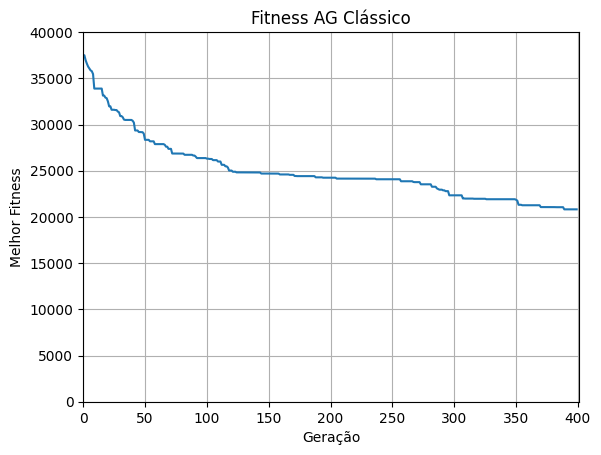

In [19]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")


plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [20]:
Melhor_rota(evolucao,df,tamanho_populacao,Juncao,Nome,Alpha =0.01)

### Resultados

In [21]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Clássico
Assimetria:             1.4290
Curtose:                2.0523
Desvio padrão:          3406.0539
Tempo de execução:      282.86 s
Gerações até convergir: 389
----------------------------------------
Melhor fitness:         20819.3884
Melhor rota encontrada:
[136  23  22  19 202  17  20 187 115 224 192   6   7  30 207  12  13 197
  43  59 181 121 177 111 109 213 146 175 156 147 151 163 165 126 209  83
  93 102  94  96  71  49  54  97  86 221  88  92 220  44 132 190 204 118
 106  64 206  61 189 191 195 217  55 110 222 223  38   5   4  51 201  82
 194 172 114 116 176 125  28  37  14  10 196   2   3  24  33   8  45  56
  68 117 188 199   0 203   9  15  16  69  60 219  18  46 130  81  29  89
  70  32  39  31  27 216  90  91 120 169  67 112 152 154 149 211 105 148
 166  84  41  34  25  98  74 135 200 143 142 171  63 184  26  58 193 107
 167  62  57  50  48  52 123  72  80  76  99 205  40 208 124 113 155 145
 168  66  65 186 108 158 140 182 214  85 185 150 139 129 198